# Phase 6 — ITS Robustness (6A / 6B / 6C)

**6A** ARMA-errors cross-check · **6B** pre-specified robustness · **6C** controls.

> **NOT in this notebook:** forecasting, volatility inference, stacked interaction
> models, or any further specification.

> **INTERPRETATION RULE, binding on all reporting below.**
> A result significant in one specification but **not** in the stationary companion,
> the ARMA-errors fit, or the pre-specified robustness set is **non-robust — not a
> finding**. Models and dates are never selected on significance. The locked levels
> specification remains the baseline; robustness variants never replace it.

**Declared before any coefficient was inspected:** the ARMA grid is the fixed 9-model
set in `robustness_core.GRID`, chosen by **AIC** (fit, not significance), with only
converged models eligible. Alternative intervention dates are taken verbatim from
`02_policy_sources/pli_intervention_dates.csv`; **no date was added, removed or
re-specified after seeing a result.**

In [1]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np
import its_core as I, robustness_core as R
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 40)
df = I.load_panel()
print("locked D_s:", I.D_S)
print("COVID drop window (robustness):", R.COVID_DROP)
print("pre-specified alternative dates:")
for b, d in R.ALT_DATES.items(): print("   ", b, d)
print("controls:", R.CONTROLS, "at", R.CONTROL_DATES)

# inline display of figures saved to ../07_figures (same files, no duplicates)
from IPython.display import Image, display
def show(figs):
    if figs is None: return
    if isinstance(figs, str): figs = [figs]
    for f in figs:
        if f: display(Image(filename=f"../07_figures/{f}"))

locked D_s: {'B1_MOBILE': '2020-08', 'B2_PHARMA': '2022-04', 'B3_AC': '2022-04', 'B4_TEXTILE': '2024-04'}
COVID drop window (robustness): ('2020-03', '2020-09')
pre-specified alternative dates:
    B1_MOBILE {'notification': '2020-04', 'elected_year1': '2021-08', 'minus3': '2020-05', 'plus3': '2020-11', 'lag6': '2021-02'}
    B2_PHARMA {'notification': '2021-03', 'fermentation_route': '2023-04', 'minus3': '2022-01', 'plus3': '2022-07', 'lag6': '2022-10'}
    B3_AC {'notification': '2021-04', 'gestation_2yr': '2023-04', 'minus3': '2022-01', 'plus3': '2022-07', 'lag6': '2022-10'}
    B4_TEXTILE {'notification': '2021-09', 'gestation_start': '2022-04', 'minus3': '2024-01', 'plus3': '2024-07'}
controls: ['C1_LEATHER', 'C2_FOOTWEAR', 'C3_COTTON'] at ['2020-08', '2022-04', '2024-04']


## 6A — ARMA-errors cross-check on the identical locked specification

In [2]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
mat = [R.ols_row(b, "A0_baseline_locked", I.design(df, b), note="LOCKED PRIMARY")
       for b in I.TREATED]
scans = {}   # retain each basket's AIC scan for 06_results/ITS_arma_aic_scan.csv
for b in I.TREATED:
    s = I.design(df, b)
    best, key, scan = R.fit_arma(s)
    scans[b] = scan
    mat.append(R.arma_row(b, "A1_ARMA_errors_AICbest", best, key))
    m1 = SARIMAX(s["ln_y"], exog=s[R.EXOG], order=(1,0,0), seasonal_order=(0,0,0,12),
                 trend="c").fit(disp=False, maxiter=500, method="lbfgs")
    mat.append(R.arma_row(b, "A2_ARMA_fixed_AR1", m1, (1,0,0,0), "fixed comparator"))
    print(f"{b:11s} AIC-best {key} converged={best.mle_retvals.get('converged',True)}")

B1_MOBILE   AIC-best (1, 1, 0, 0) converged=True


B2_PHARMA   AIC-best (1, 0, 0, 0) converged=True


B3_AC       AIC-best (2, 0, 0, 0) converged=True


B4_TEXTILE  AIC-best (1, 0, 1, 0) converged=True


### 6A read-out

Point estimate, standard error and inference compared against the locked baseline and
against the Phase-5 stationary growth companion.

In [3]:
M = pd.DataFrame(mat)
prelim = pd.read_csv("../06_results/ITS_prelim_growth_companion.csv")
for b in I.TREATED:
    print(f"\n{b}")
    for _, r in M[(M.unit==b)].iterrows():
        print(f"  {r.spec:26s} {str(r.estimator)[:26]:26s} b3={r.beta3_lgp_per_month:+7.3f} "
              f"se={r.beta3_se_hac12*100:6.3f} p={r.beta3_p_hac12:.4f} conv={r.converged}")
    a = prelim[prelim.basket_id==b].iloc[0]
    print(f"  {'growth companion (Phase 5)':26s} {'OLS+HAC12':26s} "
          f"a1={a.alpha1_postshift:+7.3f}{'':14s}p={a.alpha1_postshift_p_hac12:.4f}")


B1_MOBILE
  A0_baseline_locked         OLS+HAC                    b3= -2.921 se= 2.020 p=0.1481 conv=True
  A1_ARMA_errors_AICbest     SARIMAX(1,0,1)(0,0,0)[12]  b3= -1.553 se= 1.797 p=0.3874 conv=True
  A2_ARMA_fixed_AR1          SARIMAX(1,0,0)(0,0,0)[12]  b3= -0.965 se= 1.424 p=0.4982 conv=True
  growth companion (Phase 5) OLS+HAC12                  a1= -4.148              p=0.5053

B2_PHARMA
  A0_baseline_locked         OLS+HAC                    b3= -0.134 se= 0.152 p=0.3785 conv=True
  A1_ARMA_errors_AICbest     SARIMAX(1,0,0)(0,0,0)[12]  b3= -0.145 se= 0.243 p=0.5514 conv=True
  A2_ARMA_fixed_AR1          SARIMAX(1,0,0)(0,0,0)[12]  b3= -0.145 se= 0.243 p=0.5514 conv=True
  growth companion (Phase 5) OLS+HAC12                  a1= +0.529              p=0.5897

B3_AC
  A0_baseline_locked         OLS+HAC                    b3= +0.874 se= 0.272 p=0.0013 conv=True
  A1_ARMA_errors_AICbest     SARIMAX(2,0,0)(0,0,0)[12]  b3= +0.852 se= 0.390 p=0.0287 conv=True
  A2_ARMA_fixed_AR1      

## 6B — Pre-specified robustness

### 6B.1 COVID-adjusted: drop Mar–Sep 2020

In [4]:
for b in I.TREATED:
    s = R.drop_covid(I.design(df, b))
    mat.append(R.ols_row(b, "B1_dropCOVID_MarSep2020", s, note=f"n={len(s)}"))
print("done — 7 months dropped per basket")

done — 7 months dropped per basket


### 6B.2 Pre-specified alternative intervention dates

Taken verbatim from the registry. Every date was fixed in Phase 2; none was chosen or
altered after seeing an estimate.

In [5]:
for b in I.TREATED:
    for tag, d in R.ALT_DATES[b].items():
        mat.append(R.ols_row(b, f"B2_alt_{tag}_{d}", R.design_at(df, b, d),
                             note="pre-specified in registry"))
print("done")

done


### 6B.3 B1 `Transition_t` — carried forward unchanged from Phase 5

In [6]:
s = I.design(df, "B1_MOBILE", transition=True)
mat.append(R.ols_row("B1_MOBILE", "B3_Transition_JanApr2022", s,
                     cols=R.EXOG + ["Transition"],
                     note="carried forward unchanged from Phase 5"))
print("carried forward")

carried forward


### 6B.4 Structural-break diagnostic on COVID-adjusted data

Two complementary diagnostics: a **Quandt–Andrews supF** (classical max-Chow scanning
candidate dates with 15% trimming — the argmax is a point estimate of an *unknown*
break, not a test that the locked date is the break), and a **Bai–Perron-style**
multiple-break detection on the seasonally and COVID-adjusted residual series.

In [7]:
brk = []
for b in I.TREATED:
    s = R.drop_covid(I.design(df, b))
    _, dt, f = R.sup_f(s)
    bp = R.bai_perron(s, n_bkps=2)
    brk.append(dict(basket_id=b, locked_Ds=I.D_S[b], supF_stat=round(f,2),
                    supF_argmax=dt.strftime("%Y-%m"), bai_perron_breaks="|".join(bp)))
pd.DataFrame(brk)

,basket_id,locked_Ds,supF_stat,supF_argmax,bai_perron_breaks
0,B1_MOBILE,2020-08,20.64,2020-10,2018-09|2025-07
1,B2_PHARMA,2022-04,11.77,2021-02,2019-02|2025-07
2,B3_AC,2022-04,14.63,2021-07,2018-09|2024-09
3,B4_TEXTILE,2024-04,21.62,2020-10,2020-12|2021-10


## 6C — Controls

The identical segmented specification, estimated on C1, C2 and C3 at **each
pre-specified treated date** used as a placebo break.

> **This is a descriptive placebo comparison, not a causal contrast.** Two separately
> estimated coefficients carry no standard error on their difference. A formal stacked
> `Treated × TimeAfter` interaction — which would be a difference-in-differences and
> would require defending parallel trends — is **not** run here and is not implied by
> anything below.

In [8]:
for c in R.CONTROLS:
    for d in R.CONTROL_DATES:
        mat.append(R.ols_row(c, f"C_control_at_{d}", R.design_at(df, c, d),
                             note="placebo date; DESCRIPTIVE ONLY - no causal contrast"))
M = pd.DataFrame(mat)
M[M.unit.str.startswith("C")][["unit","spec","beta3_lgp_per_month","beta3_p_hac12"]]

,unit,spec,beta3_lgp_per_month,beta3_p_hac12
36,C1_LEATHER,C_control_at_2020-08,0.635,0.0624
37,C1_LEATHER,C_control_at_2022-04,0.053,0.8753
38,C1_LEATHER,C_control_at_2024-04,-0.090,0.6218
39,C2_FOOTWEAR,C_control_at_2020-08,0.845,0.0324
40,C2_FOOTWEAR,C_control_at_2022-04,-0.073,0.8509
41,C2_FOOTWEAR,C_control_at_2024-04,-0.248,0.3735
42,C3_COTTON,C_control_at_2020-08,-0.259,0.2634
43,C3_COTTON,C_control_at_2022-04,-0.765,0.0365
44,C3_COTTON,C_control_at_2024-04,0.252,0.3369


### Sign and significance stability across every specification

In [9]:
for b in I.TREATED:
    d = M[M.unit==b]; sg = np.sign(d.beta3_lgp_per_month)
    print(f"{b:11s} specs={len(d):2d}  sign +{(sg>0).sum()}/-{(sg<0).sum()}  "
          f"sig@5%={int((d.beta3_p_hac12<0.05).sum())}/{len(d)}  "
          f"range=[{d.beta3_lgp_per_month.min():+.3f}, {d.beta3_lgp_per_month.max():+.3f}]")
ctl = M[M.unit.str.startswith("C")]
print(f"\nCONTROL regressions significant at 5%: {int((ctl.beta3_p_hac12<0.05).sum())}/{len(ctl)} "
      f"(under a true null, ~0.45 of 9 expected)")

B1_MOBILE   specs=10  sign +0/-10  sig@5%=3/10  range=[-5.596, -0.216]
B2_PHARMA   specs= 9  sign +0/-9  sig@5%=1/9  range=[-0.549, -0.049]
B3_AC       specs= 9  sign +9/-0  sig@5%=8/9  range=[+0.852, +1.109]
B4_TEXTILE  specs= 8  sign +5/-3  sig@5%=1/8  range=[-0.344, +0.602]

CONTROL regressions significant at 5%: 2/9 (under a true null, ~0.45 of 9 expected)


## Save

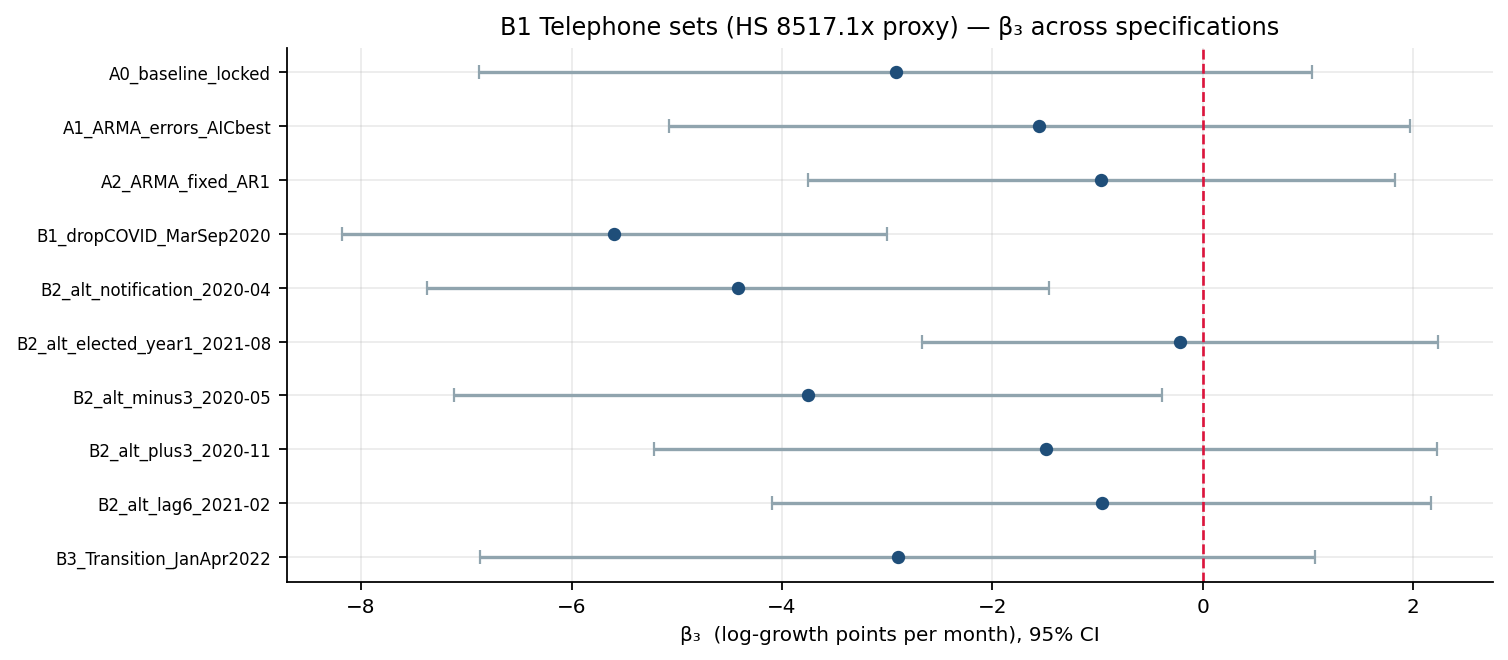

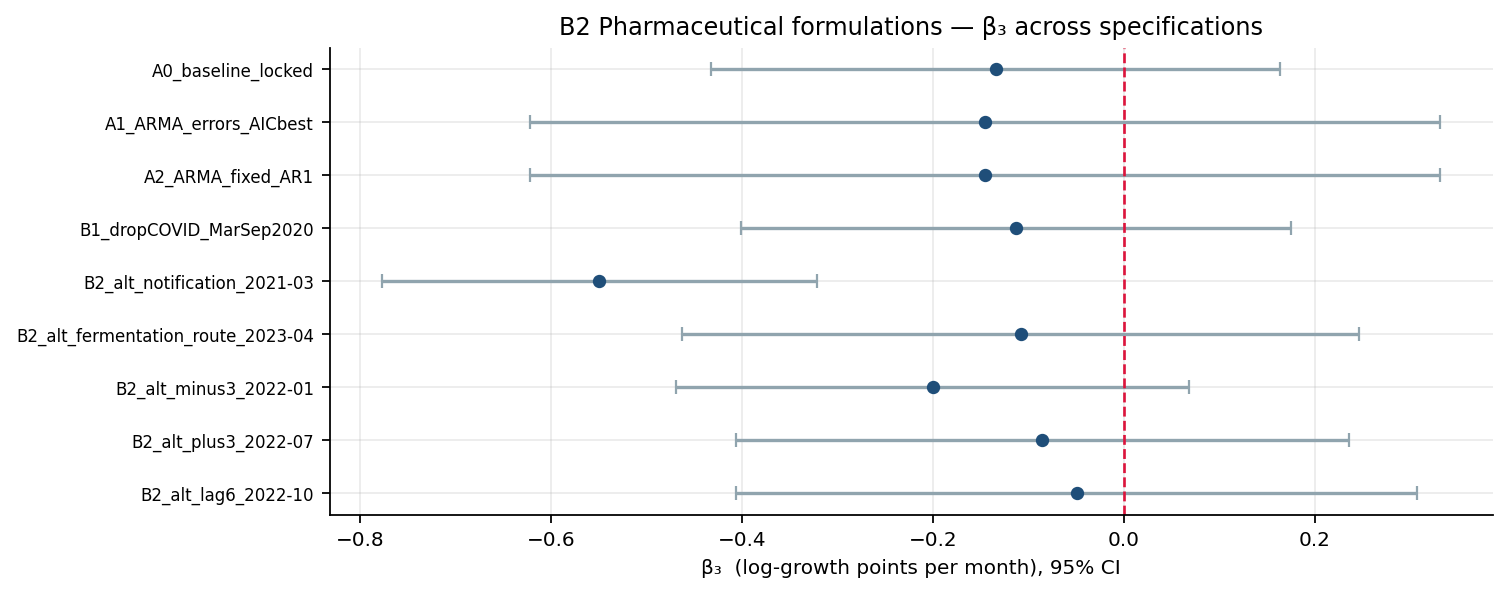

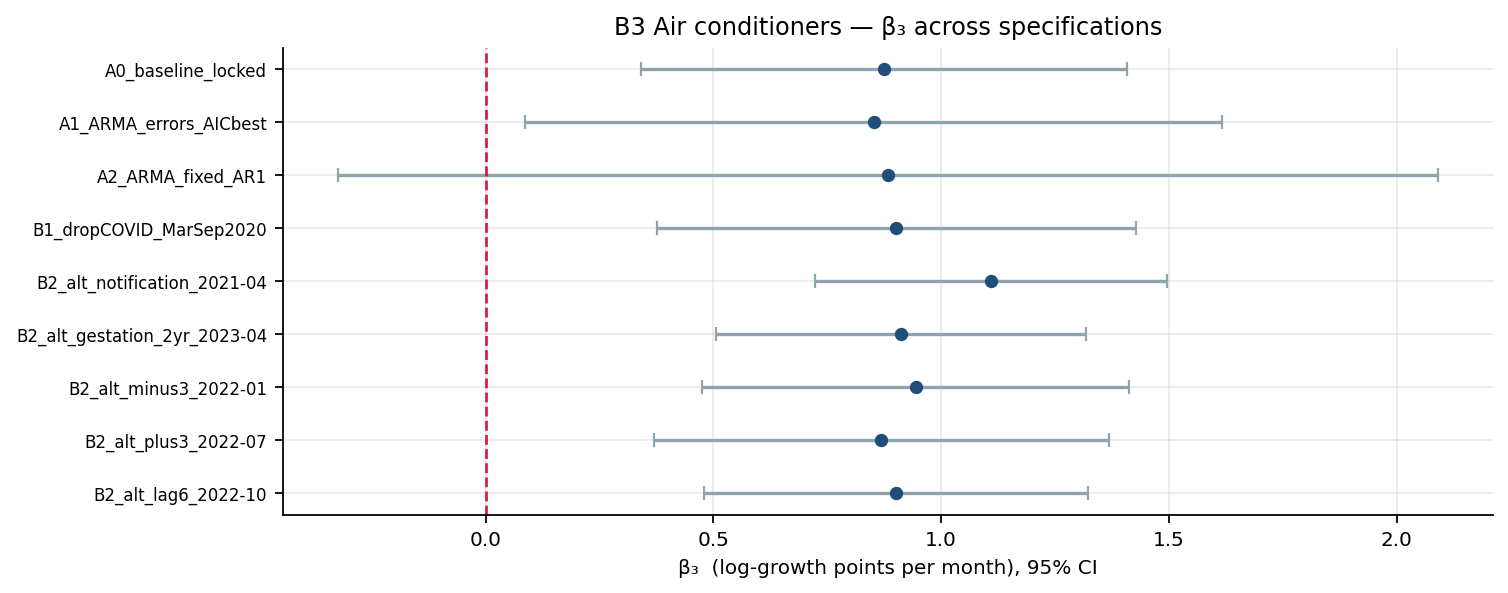

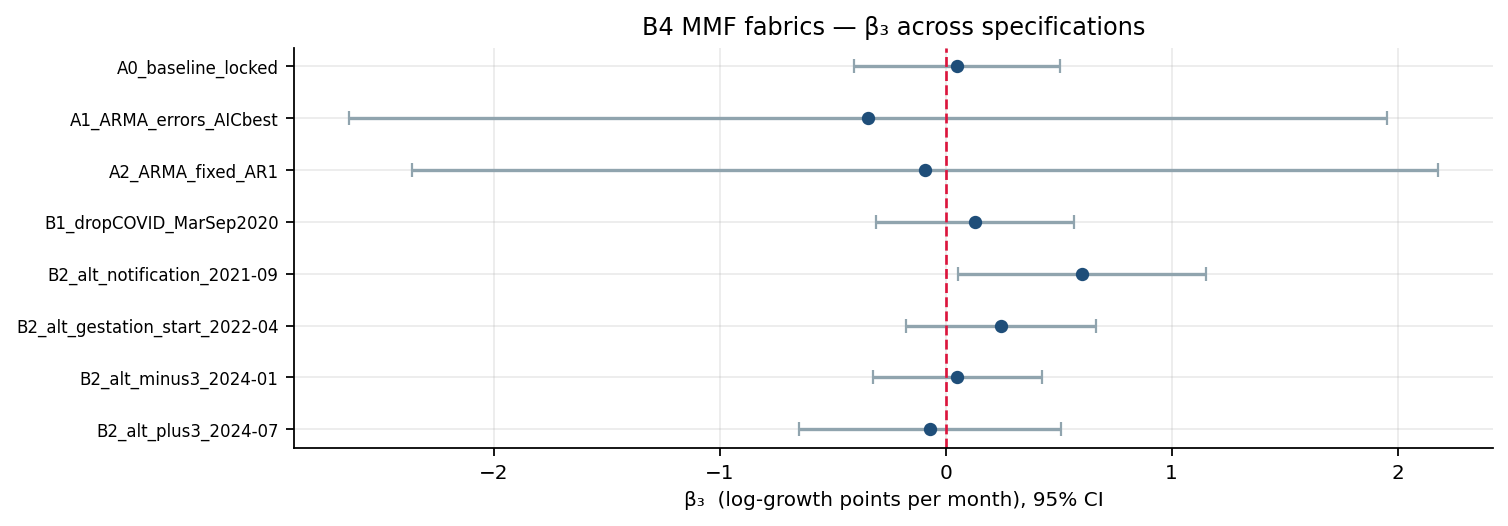

matrix rows=45  specs=24  figures=4


In [10]:
# se_type distinguishes Newey-West HAC rows from the ARMA rows, whose p-values are
# ML z-based (stored in the *_hac12 columns for table layout only).
M.insert(3, "se_type", np.where(M.spec.str.startswith(("A1","A2")),
        "ML (SARIMAX z-based) - stored in *_hac12 columns for layout; NOT HAC", "Newey-West HAC"))
M.to_csv("../06_results/ITS_robustness_matrix.csv", index=False)
pd.DataFrame(brk).to_csv("../06_results/ITS_structural_breaks.csv", index=False)
pd.concat({k: v for k, v in scans.items()}, names=["basket"]).reset_index(level=0)\
    .to_csv("../06_results/ITS_arma_aic_scan.csv", index=False)
figs = [R.plot_robustness(M, b) for b in I.TREATED]
show(figs)
print(f"matrix rows={len(M)}  specs={M.spec.nunique()}  figures={len([f for f in figs if f])}")

---
## End of robustness phase

6A-6C complete. The volatility and R12 analyses run in `05_volatility_R12.py`;
the exploratory counterfactual forecasting follows in `04_forecasting.ipynb`.